# SOLER X-ray Imaging Analysis Workflow

This workflow focuses on the construction of images from STIX pixel data using ``stixpy`` and ``xrayvisim``. 

The initial part of this demonstration is mostly taken from the ``stixpy`` examples which can be found at [STIXpy imaging example.](https://stixpy.readthedocs.io/en/stable/generated/gallery/imaging_demo.html "STIXpy Imaging Example")



How to create visibility from pixel data and make images.

The example uses ``stixpy`` to obtain STIX pixel data and convert these into visibilities and ``xrayvisim``
to make the images.


Initially each step is displayed in order to give an overview of the image generation process. Then these processes are functionalised so that images for different time and energy ranges can be created more easily.

In [1]:
import logging
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.constants import c
from sunpy.coordinates import HeliographicStonyhurst, Helioprojective
from sunpy.map import Map, make_fitswcs_header
from sunpy.time import TimeRange
from sunpy.net import Fido, attrs as a
import sunpy.map
from xrayvision.clean import vis_clean
from xrayvision.imaging import vis_to_image, vis_to_map
from xrayvision.mem import mem, resistant_mean
import os
 
from stixpy.calibration.visibility import calibrate_visibility, create_meta_pixels, create_visibility
from stixpy.coordinates.frames import STIXImaging
from stixpy.coordinates.transforms import get_hpc_info
from sunpy.coordinates import get_body_heliographic_stonyhurst, get_horizons_coord
from stixpy.imaging.em import em
from stixpy.map.stix import STIXMap  # noqa
from stixpy.product import Product

from matplotlib import pyplot as plt

import pandas as pd
from datetime import timedelta

from helper_functions import create_maps, ltc_calc

warnings.filterwarnings("ignore")
logger = logging.getLogger(__name__)

SyntaxError: f-string: unmatched '(' (helper_functions.py, line 239)

Set-up download 

In [2]:
instrument = a.Instrument.stix
product = a.stix.DataProduct.sci_xray_cpd	

download_dir = './data/'
os.makedirs(download_dir,exist_ok=True)

Download science file 

In [3]:
# Define search parameters
start_time = '2026-01-18T17:40:00'
end_time = '2026-01-18T17:55:00'
time = a.Time(start_time, end_time)

# Search + latest version
resp = Fido.search(instrument, time, product)
sci_table = resp['stix']
sci_table.filter_for_latest_version()
sci_table

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2026-01-18 16:44:24.000,2026-01-18 18:15:59.000,STIX,L1,SCI,sci-xray-cpd,V02,2601189567


In [4]:
# Select desired science file from the list and download using Fido.fetch
sci_file_download = Fido.fetch(sci_table[0], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.85file/s]


Download background file

In order to find a background file for a specific event the [STIX datacenter](https://datacenter.stix.i4ds.net/ "STIX datacenter") can be used by inputting the science file UID into the search bar and selecting "interactive analysis" from which a suitable background file can be identified. 

For this example a background file has been pre-selected using this method. 

In [5]:
# Define search parameters
start_time_bkg = '2026-01-17T15:00:00'
end_time_bkg = '2026-01-17T20:00:00'
time_bkg = a.Time(start_time_bkg, end_time_bkg)

# Search + latest version
resp_bkg = Fido.search(instrument, time_bkg, product)
bkg_table = resp_bkg['stix']
bkg_table.filter_for_latest_version()
bkg_table

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2026-01-17 14:38:34.000,2026-01-17 15:36:29.000,STIX,L1,SCI,sci-xray-cpd,V02,2601179005
2026-01-17 15:49:49.000,2026-01-17 15:53:22.000,STIX,L1,SCI,sci-xray-cpd,V02,2601173908
2026-01-17 16:07:22.000,2026-01-17 16:26:56.000,STIX,L1,SCI,sci-xray-cpd,V02,2601176033
2026-01-17 16:33:16.000,2026-01-17 16:52:42.000,STIX,L1,SCI,sci-xray-cpd,V02,2601171489
2026-01-17 17:24:42.000,2026-01-17 17:51:57.000,STIX,L1,SCI,sci-xray-cpd,V02,2601173704
2026-01-17 17:57:17.000,2026-01-17 18:42:02.000,STIX,L1,SCI,sci-xray-cpd,V02,2601173771
2026-01-17 19:04:57.000,2026-01-17 19:27:28.000,STIX,L1,SCI,sci-xray-cpd,V02,2601176800
2026-01-17 19:32:28.000,2026-01-17 20:08:38.000,STIX,L1,SCI,sci-xray-cpd,V02,2601171077


In [6]:
bkg_file_download = Fido.fetch(bkg_table[0], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.85file/s]


Read science file as Product



In [7]:
cpd_sci = Product(sci_file_download[0])
cpd_sci

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7fd882d8f8f0>
    Start: 2026-01-18 16:44:24
    End:   2026-01-18 18:15:59
    Center:2026-01-18 17:30:11
    Duration:0.06359606481481461 days or
           1.5263055555555507 hours or
           91.57833333333303 minutes or
           5494.6999999999825 seconds
    DetectorMasks
    [0...2251]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...2251]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

Read background file as Product



In [8]:
cpd_bkg = Product(bkg_file_download[0])
cpd_bkg

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7fd882c2c9b0>
    Start: 2026-01-17 14:38:34
    End:   2026-01-17 15:36:29
    Center:2026-01-17 15:07:31
    Duration:0.04022685185185182 days or
           0.9654444444444437 hours or
           57.92666666666662 minutes or
           3475.599999999997 seconds
    DetectorMasks
    [0...54]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...54]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,_,_,_,_,_,_,_,_,_,_,_,_,_,_]

Plot timeseries of science data to select a suitable time range for imaging

In [9]:
# Print out the energy bins so that the correct indices can be selected for the timeseries plot
print(*cpd_sci.energies)

channel e_low e_high
         keV   keV  
------- ----- ------
      0   4.0    5.0 channel e_low e_high
         keV   keV  
------- ----- ------
      1   5.0    6.0 channel e_low e_high
         keV   keV  
------- ----- ------
      2   6.0    7.0 channel e_low e_high
         keV   keV  
------- ----- ------
      3   7.0    8.0 channel e_low e_high
         keV   keV  
------- ----- ------
      4   8.0    9.0 channel e_low e_high
         keV   keV  
------- ----- ------
      5   9.0   10.0 channel e_low e_high
         keV   keV  
------- ----- ------
      6  10.0   11.0 channel e_low e_high
         keV   keV  
------- ----- ------
      7  11.0   12.0 channel e_low e_high
         keV   keV  
------- ----- ------
      8  12.0   13.0 channel e_low e_high
         keV   keV  
------- ----- ------
      9  13.0   14.0 channel e_low e_high
         keV   keV  
------- ----- ------
     10  14.0   15.0 channel e_low e_high
         keV   keV  
------- ----- ------
     11  15.0

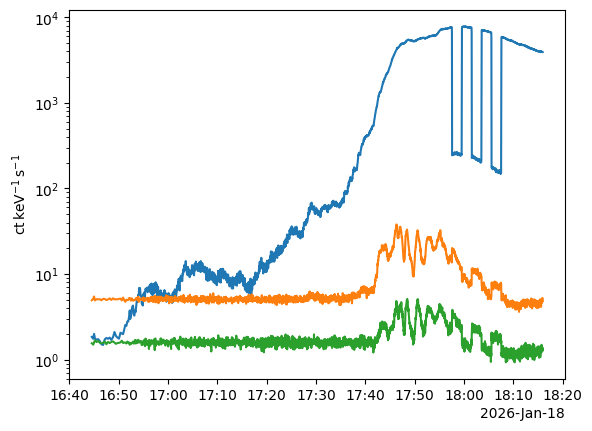

In [10]:
# Plot the timeseries for [6-12] keV and [20-50] keV (I changed the ranges already)
cpd_sci.plot_timeseries(energy_indices=[[6,11], [16,22], [22,27]])

Set time and energy ranges which will be considered for the science and the background file



In [11]:
integration_timeframe_seconds = 20 

st = pd.to_datetime("2026-01-18T17:45:00")
et = st + timedelta(seconds=integration_timeframe_seconds)

time_range_sci = [st, et]

In [12]:
cpd_bkg.time_range.start

<Time object: scale='utc' format='isot' value=2026-01-17T14:38:34.149>

In [13]:
time_range_bkg = [
    "2026-01-17T15:00:00",
    "2026-01-18T17:55:00",
]  # Set this range larger than the actual observation time

In [14]:
energy_range = [6, 12] * u.keV

Create the meta pixel, A, B, C, D for the science and the background data



In [15]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

meta_pixels_bkg = create_meta_pixels(
    cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

Perform background subtraction



In [16]:
meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    )
}

Create visibilities from the meta pixels



In [17]:
meta_pixels_bkg_subtracted

{'abcd_rate_kev': <Quantity [[272.78412679, 265.72918861, 268.89681465, 271.07966798],
            [134.14676871, 140.02409036, 162.56626544, 176.32642096],
            [ 91.6532751 , 157.6996179 , 310.94270527, 256.14280085],
            [247.26268906, 294.52398568, 168.13418098, 135.46766628],
            [180.12629477, 185.37577362, 191.87705079, 184.67377688],
            [149.40692892, 148.77349812, 166.27263687, 173.25518134],
            [232.85387762, 228.99032789, 227.98905315, 235.07062725],
            [200.13113088, 232.24242754, 186.43277066, 157.54672134],
            [276.32730134, 261.77424522, 272.29134823, 110.64304271],
            [ 53.87577667,   5.71366762,   6.043273  ,  60.85771152],
            [ 79.3581242 ,  89.69244384,  92.6400217 ,  90.10794185],
            [ 94.15915164,  99.45558716, 103.71960053, 101.47487441],
            [ 26.41069942,  29.77760305,  31.92822298,  33.1007299 ],
            [226.78783601, 122.59004745, 204.20115534, 308.70843077],
   

Calculate the total nunber of counts in this image

In [18]:
tot = (meta_pixels_bkg_subtracted['abcd_rate_kev_cm'] * meta_pixels_bkg_subtracted['areas']) * np.diff(meta_pixels_bkg_subtracted['energy_range']) * meta_pixels_bkg_subtracted['time_range'].seconds  
counts = np.sum(tot)
counts

<Quantity 2861422.52072436 ct>

In [19]:
vis = create_visibility(meta_pixels_bkg_subtracted)

Obtain the necessary ephemeris data create HPC 0,0 coordinate



In [20]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
center_hpc = SkyCoord(0 * u.deg, 0 * u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.84file/s]
2026-07-23T14:12:45Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:12:45 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec


Calibrate the visibilities

If not given will default to sun center flare location



In [21]:
cal_vis = calibrate_visibility(vis, flare_location=center_hpc)

2026-07-23T14:12:46Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:12:46 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.80file/s]
2026-07-23T14:12:47Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:12:47 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec


Selected detectors 10 to 7



In [22]:
# order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_7)).ravel()

Slice the visibilities to detectors 10 - 7



In [23]:
vis10_7 = cal_vis[idx]

Set up image parameters



In [24]:
imsize = [512, 512] * u.pixel  # number of pixels of the map to reconstruct
pixel = [10, 10] * u.arcsec / u.pixel  # pixel size in arcsec

Make a full disk back projection (inverse transform) map



In [25]:
bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)

Obtain the necessary ephemeris data



In [26]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
header = make_fitswcs_header(
    bp_image, coord_stix, telescope="STIX", observatory="Solar Orbiter", scale=[10, 10] * u.arcsec / u.pix
)
fd_bp_map = Map((bp_image, header))

2026-07-23T14:12:50Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:12:50 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:12:50Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:12:50 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec


Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up"
Center of STIX pointing in HPC



In [27]:
header_hp = make_fitswcs_header(
    bp_image, center_hpc, scale=[10, 10] * u.arcsec / u.pix, rotation_angle=90 * u.deg + roll
)
hp_map = Map((bp_image, header_hp))
hp_map_rotated = hp_map.rotate()

Plot the both maps



Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.83file/s]
2026-07-23T14:13:29Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:29 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:13:29Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:29 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:13:29Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:29 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:13:29Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:29 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23

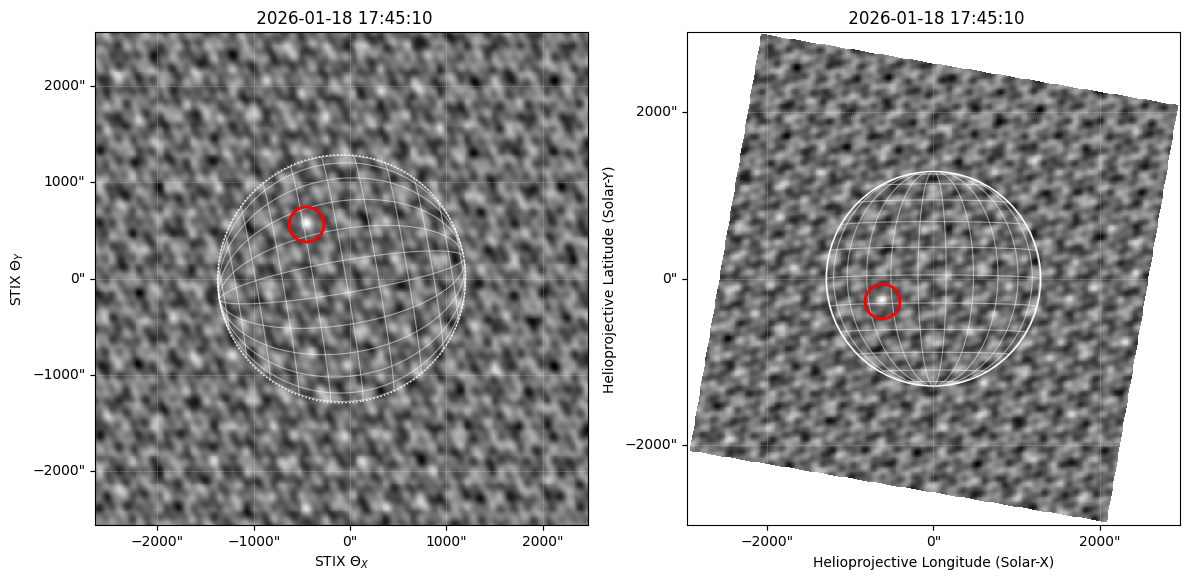

In [29]:
fig = plt.figure(layout="constrained", figsize=(12, 6))
ax = fig.subplot_mosaic(
    [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
)
fd_bp_map.plot(axes=ax["stix"])
fd_bp_map.draw_limb()
fd_bp_map.draw_grid()

hp_map_rotated.plot(axes=ax["hpc"])
hp_map_rotated.draw_limb()
hp_map_rotated.draw_grid()

max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel() * u.pixel
# because WCS axes and array are reversed
max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0])

ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)

fig.tight_layout()
plt.show()

Estimate the flare location and plot on top of back projection map. Note the coordinates
are automatically converted from the STIXImaging to Helioprojective



Use estimated flare location to create more accurate visibilities



In [30]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
)

meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    )
}

vis = create_visibility(meta_pixels_bkg_subtracted)
cal_vis = calibrate_visibility(vis, flare_location=max_stix)

2026-07-23T14:13:35Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:35 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec


Selected detectors 10 to 3
order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....



In [31]:
isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()

Create an ``xrayvsion`` visibility object



In [32]:
cal_vis.meta["offset"] = max_stix
vis10_3 = cal_vis[idx]

Set up image parameters



In [33]:
imsize = [129, 129] * u.pixel  # number of pixels of the map to reconstruct
pixel = [2, 2] * u.arcsec / u.pixel  # pixel size in arcsec

Create a back projection image with natural weighting



In [34]:
bp_nat = vis_to_image(vis10_3, imsize, pixel_size=pixel)

Create a back projection image with uniform weighting



In [35]:
bp_uni = vis_to_image(vis10_3, imsize, pixel_size=pixel, scheme="uniform")

Create a `sunpy.map.Map` with back projection



In [36]:
bp_map = vis_to_map(vis10_3, imsize, pixel_size=pixel)

Create a clean image using the clean algorithm `vis_clean`



In [37]:
niter = 200  # number of iterations, 200
gain = 0.1  # gain used in each clean iteration, 0.1
beam_width = 20 * u.arcsec
clean_map, model_map, resid_map = vis_clean(
    vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
)

2026-07-23T14:13:38Z INFO xrayvision.clean 124: Iter: 0, strength: 1393.6191263330118, location: (np.int64(63), np.int64(65))
2026-07-23 14:13:38 - xrayvision.clean - INFO: Iter: 0, strength: 1393.6191263330118, location: (np.int64(63), np.int64(65))
2026-07-23T14:13:38Z INFO xrayvision.clean 124: Iter: 25, strength: 440.78177666621224, location: (np.int64(82), np.int64(51))
2026-07-23 14:13:38 - xrayvision.clean - INFO: Iter: 25, strength: 440.78177666621224, location: (np.int64(82), np.int64(51))
2026-07-23T14:13:38Z INFO xrayvision.clean 124: Iter: 50, strength: 206.065821946533, location: (np.int64(75), np.int64(48))
2026-07-23 14:13:38 - xrayvision.clean - INFO: Iter: 50, strength: 206.065821946533, location: (np.int64(75), np.int64(48))
2026-07-23T14:13:38Z INFO xrayvision.clean 124: Iter: 75, strength: 109.20005412968099, location: (np.int64(91), np.int64(73))
2026-07-23 14:13:38 - xrayvision.clean - INFO: Iter: 75, strength: 109.20005412968099, location: (np.int64(91), np.int64

Create a sunpy map for the clean image in Helioprojective



In [38]:
header = make_fitswcs_header(
    clean_map.data,
    max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
    telescope="STIX",
    observatory="Solar Orbiter",
    scale=pixel,
    rotation_angle=90 * u.deg + roll
)

2026-07-23T14:13:41Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:13:41 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec


Create a map using the MEM GE algorithm `mem`



In [39]:
snr_value, _ = resistant_mean((np.abs(vis10_3.visibilities) / vis10_3.amplitude_uncertainty).flatten(), 3)
percent_lambda = 2 / (snr_value**2 + 90)
mem_map = mem(vis10_3, shape=imsize, pixel_size=pixel, percent_lambda=percent_lambda)

2026-07-23T14:13:41Z INFO xrayvision.mem 159: Iter: 0, Chi2: 4826.630753547074
2026-07-23 14:13:41 - xrayvision.mem - INFO: Iter: 0, Chi2: 4826.630753547074
2026-07-23T14:13:43Z INFO xrayvision.mem 159: Iter: 25, Chi2: 367.8348103717753
2026-07-23 14:13:43 - xrayvision.mem - INFO: Iter: 25, Chi2: 367.8348103717753
2026-07-23T14:13:45Z INFO xrayvision.mem 159: Iter: 50, Chi2: 67.43024876759374
2026-07-23 14:13:45 - xrayvision.mem - INFO: Iter: 50, Chi2: 67.43024876759374
2026-07-23T14:13:47Z INFO xrayvision.mem 159: Iter: 75, Chi2: 28.363438070577352
2026-07-23 14:13:47 - xrayvision.mem - INFO: Iter: 75, Chi2: 28.363438070577352
2026-07-23T14:13:49Z INFO xrayvision.mem 159: Iter: 100, Chi2: 19.09360853899404
2026-07-23 14:13:49 - xrayvision.mem - INFO: Iter: 100, Chi2: 19.09360853899404
2026-07-23T14:13:51Z INFO xrayvision.mem 510: Iter: 0, Obj function: (3102.61174197399+0j)
2026-07-23 14:13:51 - xrayvision.mem - INFO: Iter: 0, Obj function: (3102.61174197399+0j)
2026-07-23T14:13:58Z I

Create a map using the EM algorithm `EM`



In [40]:
maps_dir = './maps/'
os.makedirs(maps_dir,exist_ok=True)

In [41]:
em_map = em(
    meta_pixels_bkg_subtracted["abcd_rate_kev_cm"],
    cal_vis,
    shape=imsize,
    pixel_size=pixel,
    flare_location=max_stix,
    idx=idx
)

clean_map = Map((clean_map.data, header)).rotate()
bp_map = Map((bp_nat, header)).rotate()
mem_map = Map((mem_map.data, header)).rotate()
em_map = Map((em_map, header)).rotate()

vmax = max([clean_map.data.max(), mem_map.data.max(), em_map.data.max()])

2026-07-23T14:14:27Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:14:27 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:14:29Z INFO stixpy.imaging.em 180: Iteration: 25, StdDeV: 57.10350570750933, C-stat: 43.78007914501019
2026-07-23 14:14:29 - stixpy.imaging.em - INFO: Iteration: 25, StdDeV: 57.10350570750933, C-stat: 43.78007914501019
2026-07-23T14:14:30Z INFO stixpy.imaging.em 180: Iteration: 50, StdDeV: 18.29546311022078, C-stat: 28.162825218366084
2026-07-23 14:14:30 - stixpy.imaging.em - INFO: Iteration: 50, StdDeV: 18.29546311022078, C-stat: 28.162825218366084
2026-07-23T14:14:32Z INFO stixpy.imaging.em 180: Iteration: 75, StdDeV: 4.208319583304958, C-stat: 22.59661073748389
2026-07-23 14:14:32 - stixpy.imaging.em - INFO: Iteration: 75, StdDeV: 4.208319583304958, C-stat: 22.59661073748389
2026-07-23T14:14:33Z INFO stixpy.imaging.em 180: Iteration: 100, Std

In [42]:
# Save the EM and the MEM maps out with the selected energy and time ranges specified
mem_map.save(f'{maps_dir}stix_{int(energy_range[0].value)}-{int(energy_range[1].value)}_{st.strftime('%Y-%m-%dT%H:%M:%S')}-{et.strftime('%Y-%m-%dT%H:%M:%S')}_MEM.fits',overwrite=True)
em_map.save(f'{maps_dir}stix_{int(energy_range[0].value)}-{int(energy_range[1].value)}_{st.strftime('%Y-%m-%dT%H:%M:%S')}-{et.strftime('%Y-%m-%dT%H:%M:%S')}_EM.fits',overwrite=True)

Finally compare the images from each algorithm



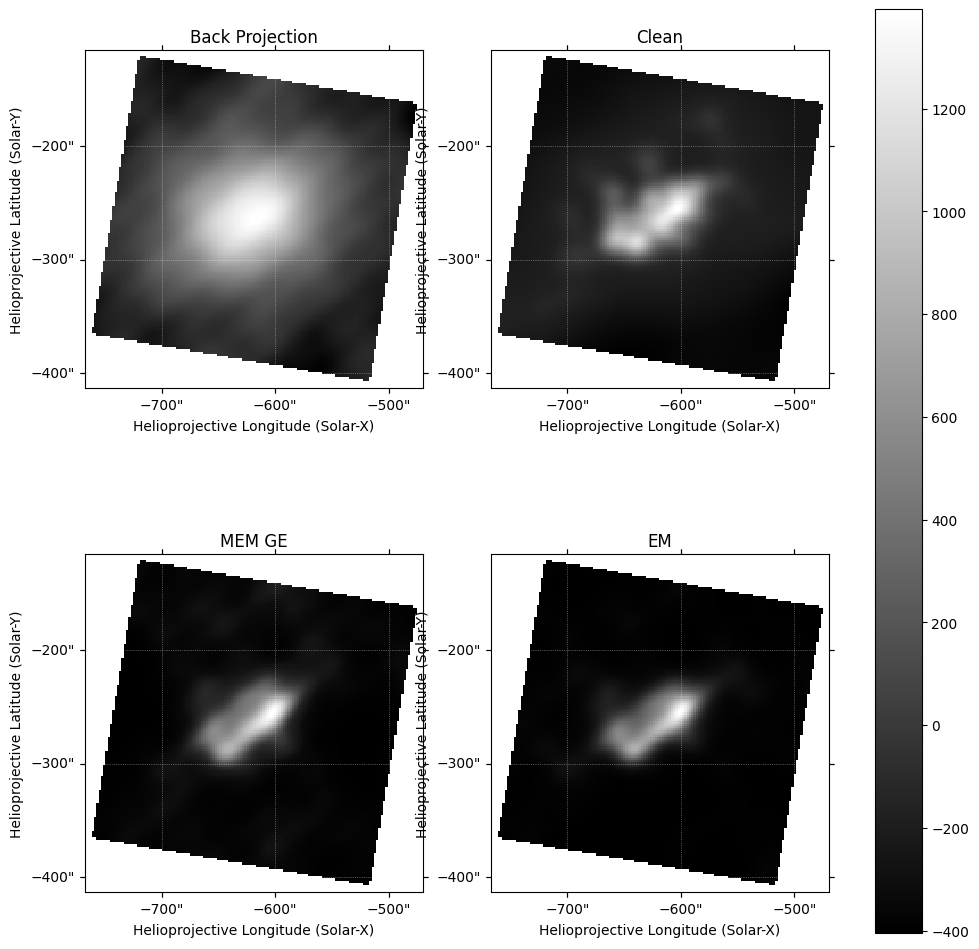

In [43]:
fig = plt.figure(figsize=(12, 12))
ax = fig.subplot_mosaic(
    [
        ["bp", "clean"],
        ["mem", "em"],
    ],
    subplot_kw={"projection": clean_map},
)
a = bp_map.plot(axes=ax["bp"])
ax["bp"].set_title("Back Projection")
b = clean_map.plot(axes=ax["clean"])
ax["clean"].set_title("Clean")
c = mem_map.plot(axes=ax["mem"])
ax["mem"].set_title("MEM GE")
d = em_map.plot(axes=ax["em"])
ax["em"].set_title("EM")
fig.colorbar(a, ax=ax.values())
plt.show()

Now that the maps have been created, we can read them back in as sunpy maps and create plots using them. 

First, use the functionalised version of the above process to create maps for the same timeframe for the thermal [6-15]keV and the non-thermal [25-85]keV.

2026-07-23T14:15:14Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:15:14 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:15:14Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:15:14 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:15:14Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:15:14 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:15:14Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:15:14 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:15:14Z INFO stixpy.coordinates.transforms 141: Using SAS point

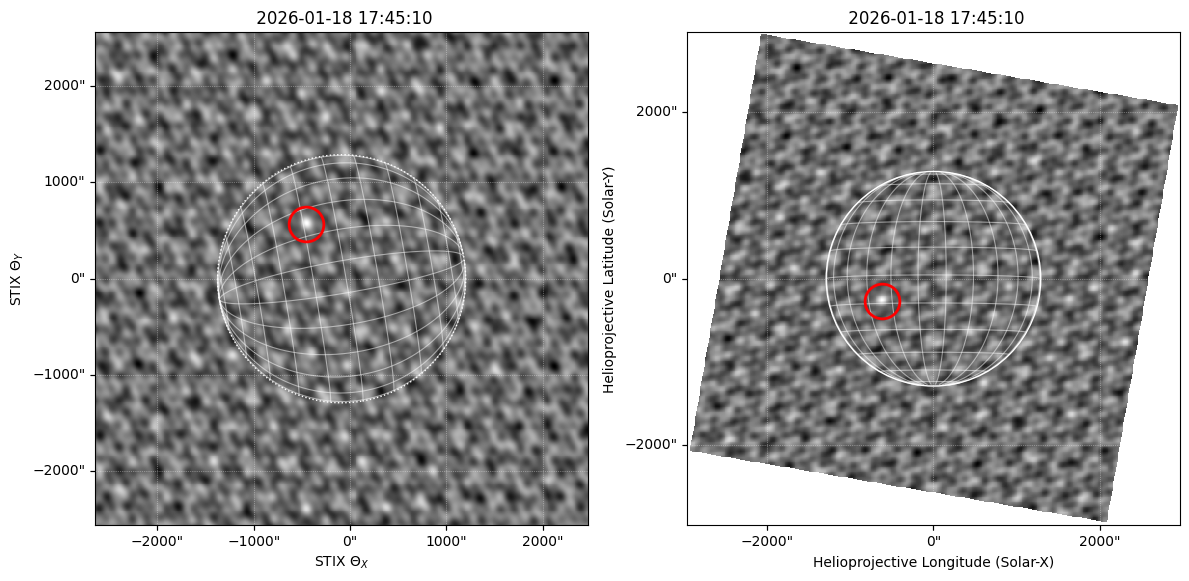

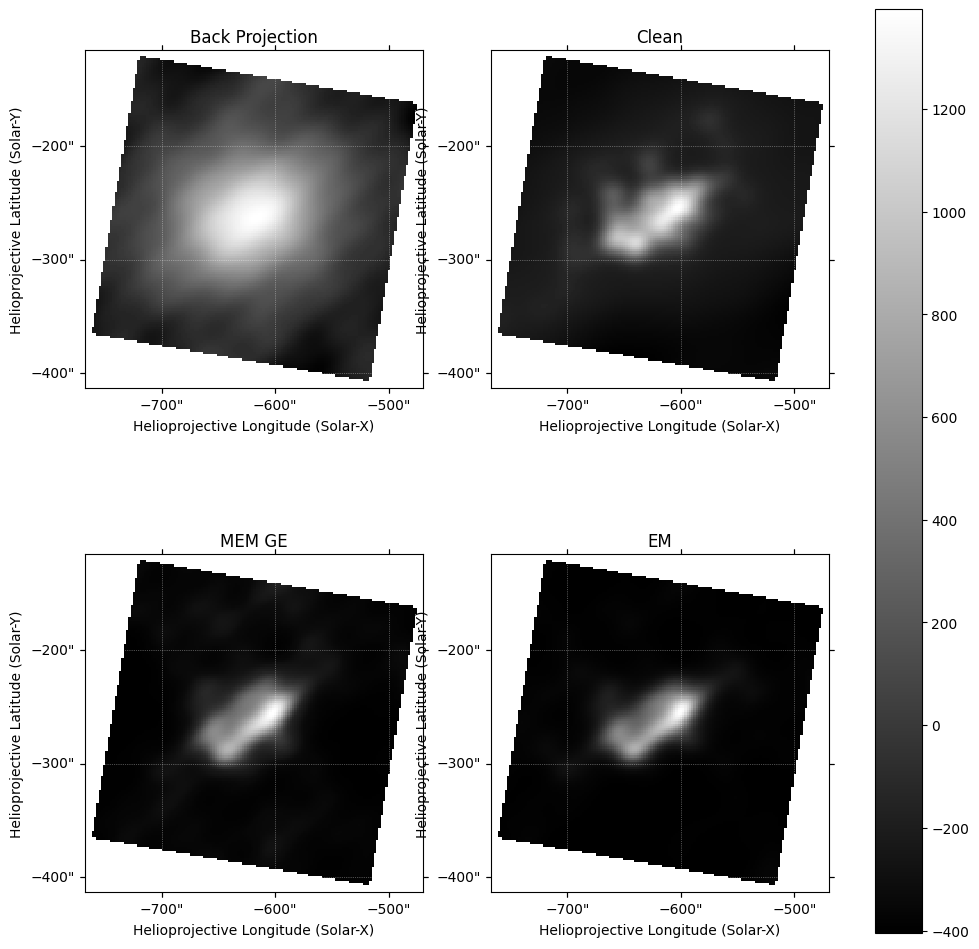

In [44]:
thermal_energy_range = [6,12]*u.keV

maps_thermal = create_maps(cpd_sci,
                   cpd_bkg,
                   st,
                   et,
                   energy_range=thermal_energy_range,
                   save_directory='./maps/')

2026-07-23T14:16:56Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:16:56 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:16:56Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:16:56 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:16:56Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:16:56 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:16:56Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23 14:16:56 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.27793392 87.1091176 ]] arcsec
2026-07-23T14:16:56Z INFO stixpy.coordinates.transforms 141: Using SAS point

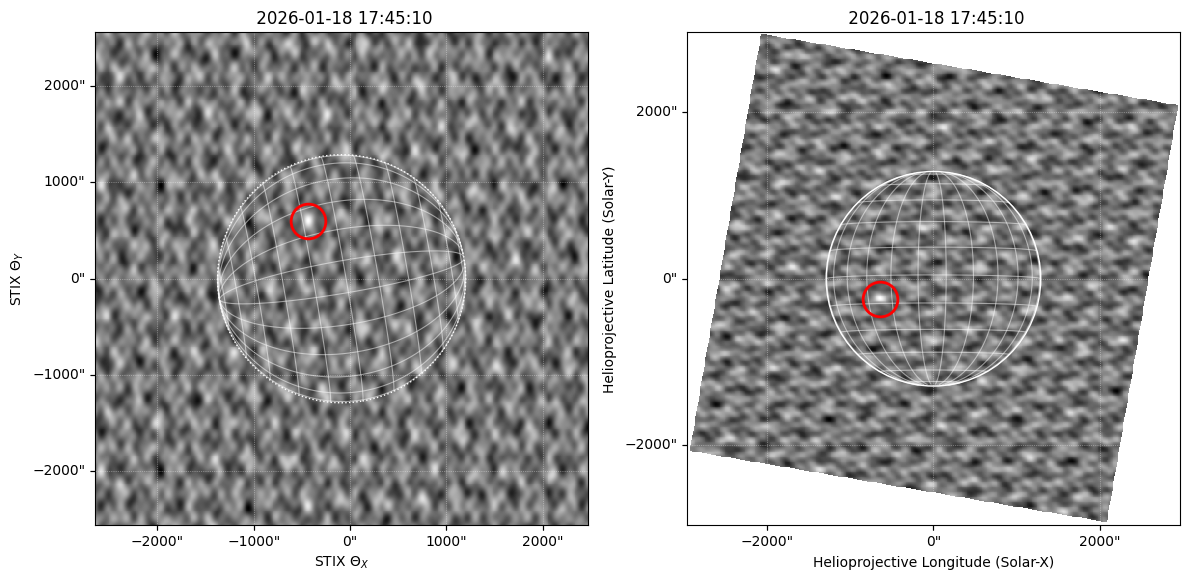

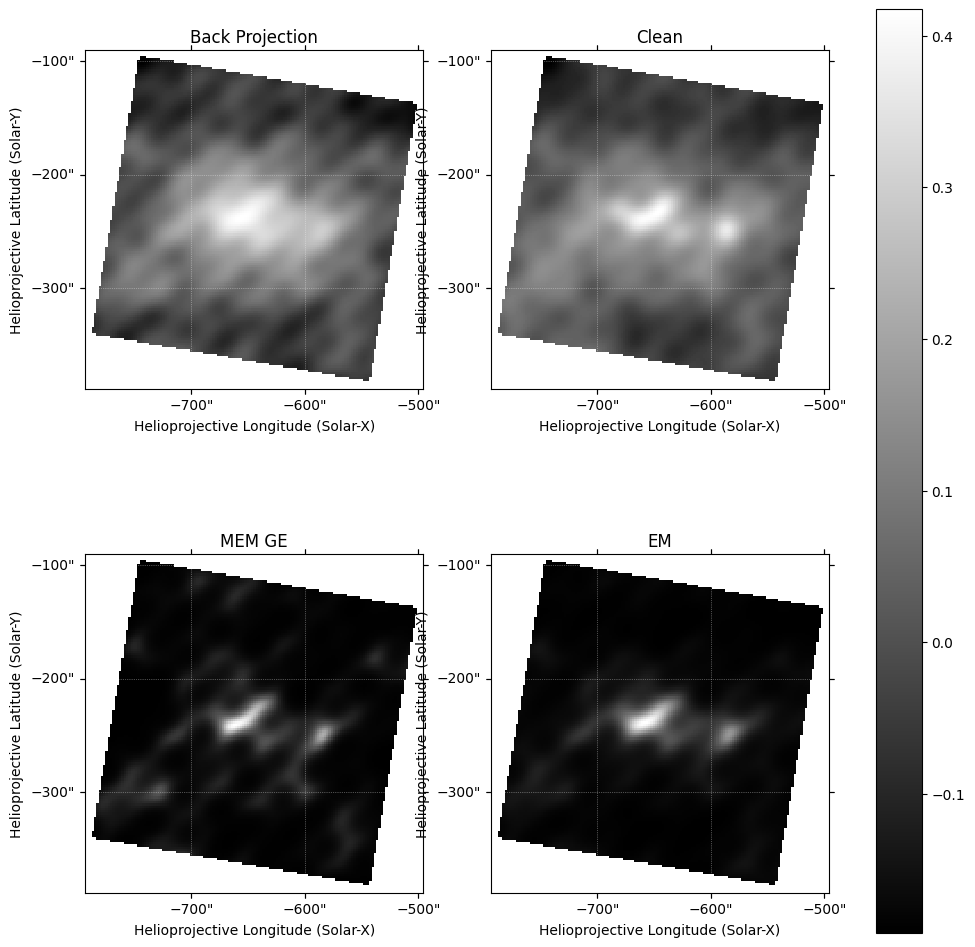

In [45]:
nonthermal_energy_range = [25,85]*u.keV

maps_nonthermal = create_maps(cpd_sci,
                   cpd_bkg,
                   st,
                   et,
                   energy_range=nonthermal_energy_range,
                   save_directory='./maps/')

In [46]:
# # Test another datetime

# integration_timeframe_seconds = 20

# maps_nonthermal = create_maps(cpd_sci,
#                    cpd_bkg,
#                    # next two lines are st and et
#                    pd.to_datetime("2026-01-18T18:00:00"),
#                    st + timedelta(seconds=integration_timeframe_seconds),
#                    energy_range=nonthermal_energy_range,
#                    save_directory='./maps/')

Now load in the maps that we have just created

In [47]:
plot_directory = './plots/'
os.makedirs(plot_directory,exist_ok=True)

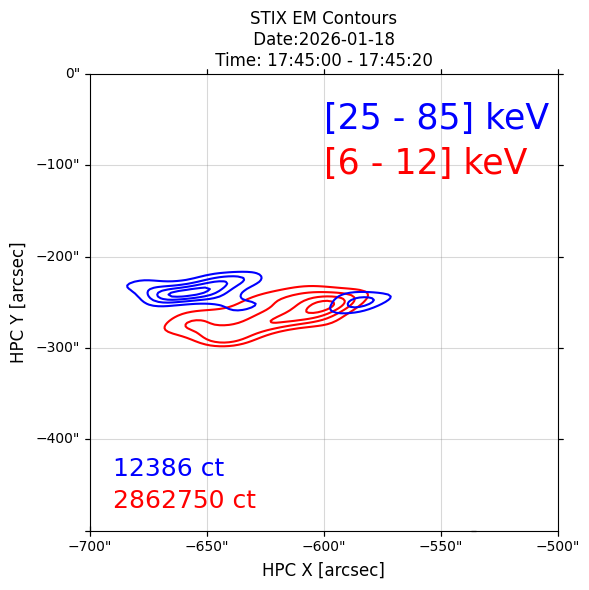

In [49]:
import matplotlib.pyplot as plt
import sunpy.map
import numpy as np

# Load maps
map_low = sunpy.map.Map(maps_thermal['em_map'])
map_high = sunpy.map.Map(maps_nonthermal['em_map'])

# Create WCS-aware figure
fig = plt.figure(figsize=[6,6], layout='constrained')
ax = fig.add_subplot(111, projection=map_low)

# Choose contour levels (as percentages of max)
levels_low = np.array([30, 50, 70, 90]) * u.percent
levels_high = np.array([30, 50, 70, 90]) * u.percent

# Plot contours
map_low.draw_contours(
    levels=levels_low,
    axes=ax,
    colors="red",
    linewidths=1.5,
    label='4-25 keV')

map_high.draw_contours(
    levels=levels_high,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-65 keV')

# Draw solar limb
map_low.draw_limb(axes=ax, color="black", linewidth=1.5)

# This section can be customiseed for different files and images to zoom in on a desired region
# xlims_world = [-1400, 1400]*u.arcsec
# ylims_world = [-1400, 1400]*u.arcsec

xlims_world = [-700, -500]*u.arcsec
ylims_world = [-500, 0]*u.arcsec

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=map_low.coordinate_frame)
pixel_coords_x, pixel_coords_y = map_low.wcs.world_to_pixel(world_coords)
ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

# Labels & title
ax.set_title(f"STIX EM Contours\n Date:{ st.strftime('%Y-%m-%d')} \n Time: {st.strftime('%H:%M:%S')} - {et.strftime('%H:%M:%S')} ")

ax.text(0.5, 0.78, f"[{int(thermal_energy_range[0].value)} - {int(thermal_energy_range[1].value)}] keV", 
        color='red', 
        fontsize=25,
        transform=ax.transAxes)

ax.text(0.5, 0.88, f"[{int(nonthermal_energy_range[0].value)} - {int(nonthermal_energy_range[1].value)}] keV", 
        color='blue', 
        fontsize=25,
        transform=ax.transAxes)

ax.text(0.05, 0.05, f"{int(maps_thermal['counts'].value)} {maps_thermal['counts'].unit}", 
        color='red', 
        fontsize=18,
        transform=ax.transAxes)

ax.text(0.05, 0.12, f"{int(maps_nonthermal['counts'].value)} {maps_nonthermal['counts'].unit}", 
        color='blue', 
        fontsize=18,
        transform=ax.transAxes)

ax.grid(color="gray", alpha=0.3)
ax.set_xlabel("HPC X [arcsec]", fontsize=12)
ax.set_ylabel("HPC Y [arcsec]", fontsize=12)
plt.tight_layout()
plt.show()

fig.savefig(f'{plot_directory}STIX_contour_plot.png',bbox_inches='tight')

Calculate Light Travel Time between STIX and Earth (AIA)

In [50]:
ltc = ltc_calc(st)
ltc

2026-07-23 14:18:10 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]


<Quantity 119.32618268 s>

Search for all of the AIA 1700 images that fall within the time range of the cpd science file after light travel time correction

In [51]:
from sunpy.net import Fido, attrs as a

st_aia_search = cpd_sci.time_range.start + ltc
et_aia_search = cpd_sci.time_range.end + ltc

res = Fido.search(a.Time(st_aia_search, et_aia_search),
                  a.Wavelength(1700*u.angstrom),
                  a.jsoc.Series('aia.lev1_uv_24s'))
res

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str20,str7,str5,int64,int64
2026-01-18T16:46:11Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:46:35Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:46:59Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:47:23Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:47:47Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:48:11Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:48:35Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:48:59Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T16:49:23Z,SDO/AIA,AIA_3,1700,2306


Now perform a more targeted search around the integration window

Here you must insert a string containing a JSOC registered email address to perform the download!

In [52]:
st_aia_search = st - timedelta(seconds=20) + timedelta(seconds=ltc.value)
et_aia_search = et + timedelta(seconds=20) + timedelta(seconds=ltc.value)

res = Fido.search(a.Time(st_aia_search, et_aia_search),
                  a.Wavelength(1700*u.angstrom),
                  a.jsoc.Series('aia.lev1_uv_24s'),
                  a.jsoc.Notify('mnedal@nao-rozhen.org')) # mohamed.nedal.solae@gmail.com
res

T_REC,TELESCOP,INSTRUME,WAVELNTH,CAR_ROT
str20,str7,str5,int64,int64
2026-01-18T17:46:35Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T17:46:59Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T17:47:23Z,SDO/AIA,AIA_3,1700,2306
2026-01-18T17:47:47Z,SDO/AIA,AIA_3,1700,2306


Now download the AIA files

In [53]:
aia_directory = './aia/'
os.makedirs(aia_directory,exist_ok=True)

aia_download = Fido.fetch(res, path=aia_directory)

2026-07-23 14:18:28 - drms - INFO: Export request pending. [id=JSOC_20260723_012683, status=2]
2026-07-23 14:18:28 - drms - INFO: Waiting for 0 seconds...
2026-07-23 14:18:28 - sunpy - INFO: 4 URLs found for download. Full request totaling 48MB


INFO: 4 URLs found for download. Full request totaling 48MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 4/4 [00:06<00:00,  1.59s/file]


Now we can generate STIX images of the non-thermal (high-energy) emission that is originating in the chromosphere, we can then reproject this to the AIA frame of reference and overplot for comparison.

We do not repeat this for the thermal (low energy) emission as this originates higherup in the corona and there would be significant reprojection artifacts. 

In [63]:
aia_map = sunpy.map.Map('./aia/aia.lev1_uv_24s.2026-01-18T174653Z.1700.image_lev1.fits')

aia_integration_time = 20

aia_start_time = aia_map.reference_date
aia_end_time = aia_start_time + timedelta(seconds=aia_integration_time)

In [65]:
# maps_nonthermal

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.80file/s]
2026-07-23T14:28:35Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23 14:28:35 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23T14:28:35Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23 14:28:35 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  5.84file/s]
2026-07-23T14:28:35Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23 14:28:35 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23T14:28:35Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.29968735 87.1258789 ]] arcsec
2026-07-23 14:28:35 - stixpy.coordinates.transforms - INFO:

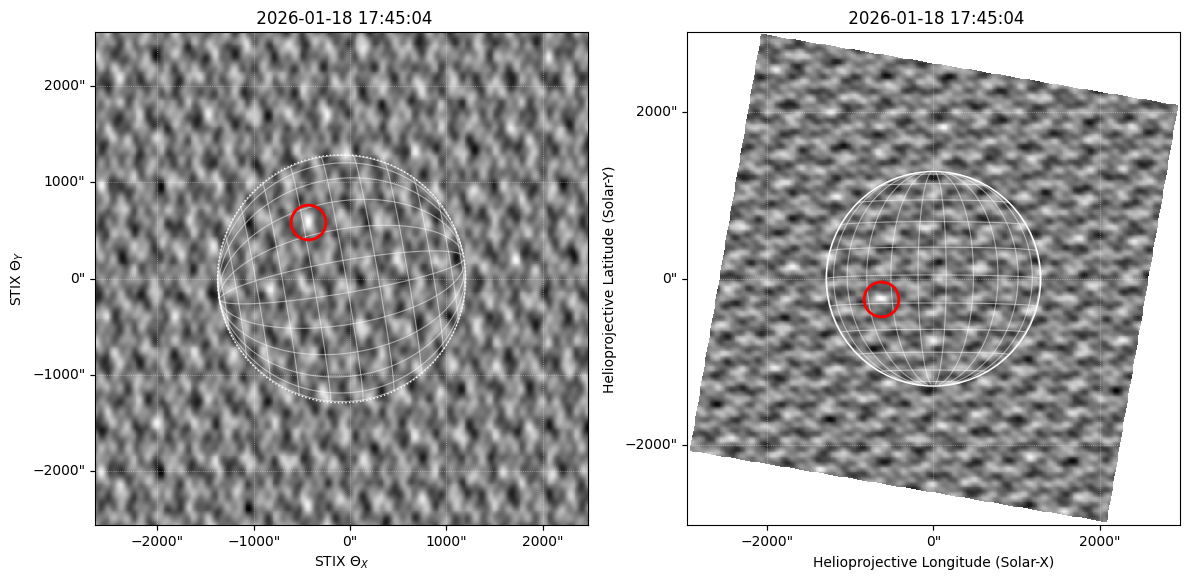

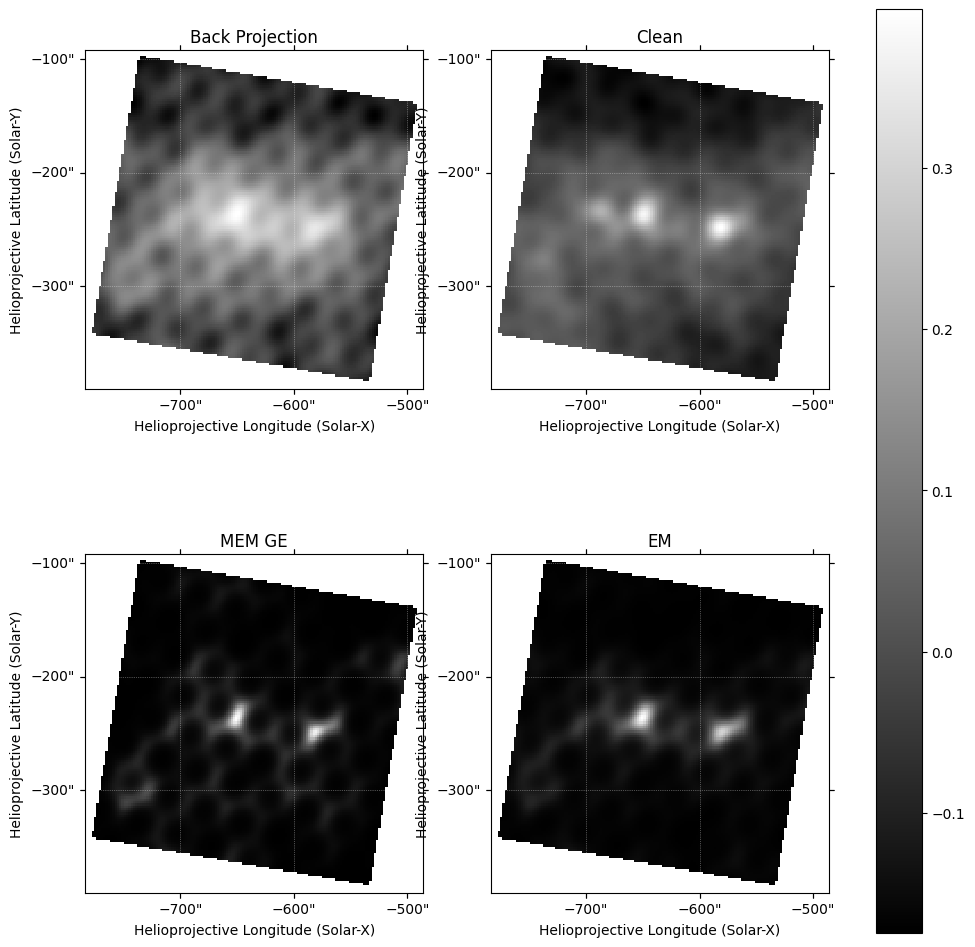

In [66]:
stx_aia_start_time = aia_start_time - ltc
stx_aia_end_time = aia_end_time - ltc

maps_nonthermal_aia = create_maps(cpd_sci,
                   cpd_bkg,
                   stx_aia_start_time,
                   stx_aia_end_time,
                   energy_range=[25,85]*u.keV, # 25,65
                   save_directory='./maps/')

In [67]:
maps_nonthermal_aia.keys()

dict_keys(['time_range', 'energy_range', 'counts', 'mem_map', 'em_map'])

In [68]:
maps_nonthermal_aia['time_range']

[<Time object: scale='utc' format='isot' value=2026-01-18T17:44:53.893>,
 <Time object: scale='utc' format='isot' value=2026-01-18T17:45:13.893>]

In [69]:
maps_nonthermal_aia['energy_range']

<Quantity [25., 85.] keV>

In [70]:
stix_nt_map = sunpy.map.Map(maps_nonthermal_aia['em_map'])
stix_nt_map_reproj = stix_nt_map.reproject_to(aia_map.wcs)

In [ ]:
stix_thermal_map = sunpy.map.Map(maps_thermal['em_map'])
stix_nonthermal_map = sunpy.map.Map(maps_nonthermal['em_map'])

stix_thermal_map_reproj = stix_thermal_map.reproject_to(aia_map.wcs)
stix_nonthermal_map_reproj = stix_nonthermal_map.reproject_to(aia_map.wcs)


fig = plt.figure(figsize=[7,7], layout='constrained')
ax = fig.add_subplot(projection=aia_map)

aia_map.plot(axes=ax)

# Plot contours
stix_thermal_map_reproj.draw_contours(
    levels=levels_low,
    axes=ax,
    colors="red",
    linewidths=1.5,
    label='6-12 keV')

stix_nonthermal_map_reproj.draw_contours(
    levels=levels_high,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-85 keV')

# # Draw solar limb
aia_map.draw_limb(axes=ax, color="black", linewidth=1.5)

xlims_world = [-700, -500]*u.arcsec
ylims_world = [-500, 0]*u.arcsec

# Labels & title
ax.set_title(f"Time: {aia_start_time.strftime('%Y-%m-%dT%H:%M:%S')} - {aia_end_time.strftime('%Y-%m-%dT%H:%M:%S')} \n STIX Counts = {np.round(maps_nonthermal_aia['counts'])}", fontsize=20)

ax.text(0.5, 0.78, f'6-12 keV',
        color='red', 
        fontsize=20,
        transform=ax.transAxes)

ax.text(0.5, 0.88, f'25-85 keV',
        color='blue', 
        fontsize=20,
        transform=ax.transAxes)

ax.grid(color="gray", alpha=0.5)
ax.set_xlabel("HPC X [arcsec]", fontsize=20)
ax.set_ylabel("HPC Y [arcsec]", fontsize=20)

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=aia_map.coordinate_frame)
pixel_coords_x, pixel_coords_y = aia_map.wcs.world_to_pixel(world_coords)
ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

fig.tight_layout()
plt.show()

NameError: name 'stix_nt_map_reproj' is not defined

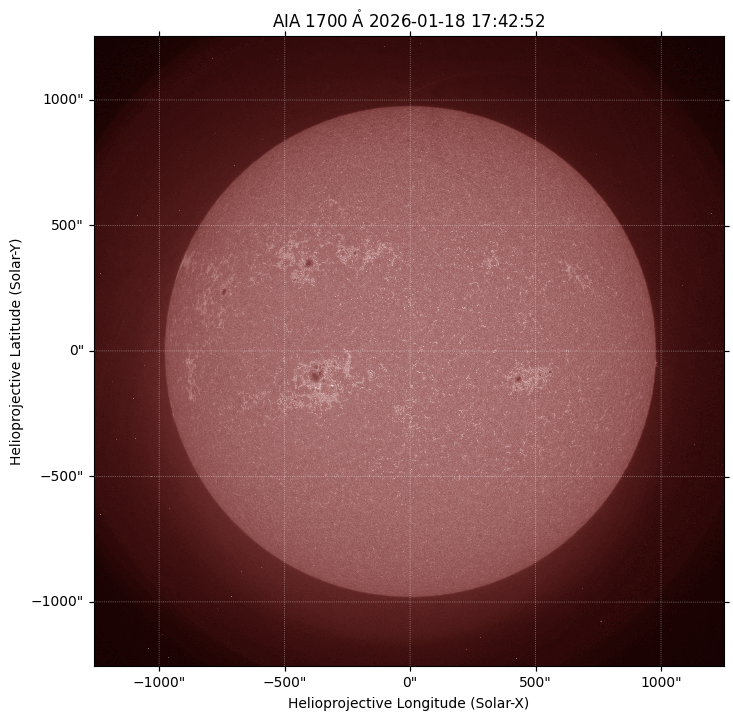

In [63]:
fs = 20
fsa = 24 # fontsize

fig = plt.figure(figsize=(18, 18))
ax = fig.add_subplot(211, projection=aia_map)

# Choose contour levels (as percentages of max)
levels_th = np.array([30, 50, 70, 90]) * u.percent
levels_nt = np.array([30, 50, 70, 90]) * u.percent

aia_map.plot(axes=ax)

# Plot contours
stix_nt_map_reproj.draw_contours(
    levels=levels_nt,
    axes=ax,
    colors="blue",
    linewidths=1.5,
    label='25-65 keV')

# # Draw solar limb
aia_map.draw_limb(axes=ax, color="black", linewidth=1.5)

# xlims_world = [-1400, 1400]*u.arcsec
# ylims_world = [-1400, 1400]*u.arcsec

xlims_world = [-700, -500]*u.arcsec
ylims_world = [-500, 0]*u.arcsec

world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=aia_map.coordinate_frame)
pixel_coords_x, pixel_coords_y = aia_map.wcs.world_to_pixel(world_coords)

ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

# Labels & title
ax.set_title(f"Time: {aia_start_time.strftime('%Y-%m-%dT%H:%M:%S')} - {aia_end_time.strftime('%Y-%m-%dT%H:%M:%S')} \n STIX Counts = {np.round(maps_nonthermal_aia['counts'])}", fontsize=20)


ax.text(0.65, 0.88, 
        "25–65 keV", 
        color='blue', 
        fontsize=25,
        transform=ax.transAxes,   
        bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.5
        ))

ax.grid(color="gray", alpha=0.5)

ax.set_xlabel("HPC X [arcsec]", fontsize=fsa)
ax.set_ylabel("HPC Y [arcsec]", fontsize=fsa)

fig.savefig(f'{plot_directory}AIA_1700_STIX_comp_plot.png',bbox_inches='tight')

plt.show()